<a href="https://colab.research.google.com/github/Mister-Raggs/saved-notebooks/blob/main/workshops/lora-alignment/colab_model_alignment_em_tutor_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Alignment Lab

## Setup

In [1]:
!wget -O lab.zip https://github.com/DerrickJ1612/model-alignment-lab/archive/refs/heads/workshop_ucsd.zip
!unzip -q lab.zip
%cd model-alignment-lab-workshop_ucsd
!pip install -q -r requirements-colab.txt
!pip uninstall -y torchao

--2026-05-13 23:08:39--  https://github.com/DerrickJ1612/model-alignment-lab/archive/refs/heads/workshop_ucsd.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/DerrickJ1612/model-alignment-lab/zip/refs/heads/workshop_ucsd [following]
--2026-05-13 23:08:39--  https://codeload.github.com/DerrickJ1612/model-alignment-lab/zip/refs/heads/workshop_ucsd
Resolving codeload.github.com (codeload.github.com)... 140.82.113.10
Connecting to codeload.github.com (codeload.github.com)|140.82.113.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 850096 (830K) [application/zip]
Saving to: ‘lab.zip’

lab.zip             100%[===================>] 830.17K  --.-KB/s    in 0.06s   

2026-05-13 23:08:39 (13.1 MB/s) - ‘lab.zip’ saved [850096/850096]

/content/model-alignment-lab-workshop_ucsd
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))

from model_alignment_lab.utils.helpers import generate_response, format_example
from model_alignment_lab.evaluation.eval import log_parser, evaluate_tutor_schema_df

from datetime import datetime

ts = datetime.now().strftime("%Y%m%d_%H%M%S")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
## Path Setup
root = Path.cwd()
output_dir = root/"outputs"
datasets_dir = root/"datasets"/"structured_json"
root

PosixPath('/content/model-alignment-lab-workshop_ucsd')

In [4]:
print(root.is_dir())
print(output_dir.is_dir())
print(datasets_dir.is_dir())

True
True
True


## Base Model Preparation

In [5]:
MODEL_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32
)

model = model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 960, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=960, out_features=960, bias=False)
          (k_proj): Linear(in_features=960, out_features=320, bias=False)
          (v_proj): Linear(in_features=960, out_features=320, bias=False)
          (o_proj): Linear(in_features=960, out_features=960, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=960, out_features=2560, bias=False)
          (up_proj): Linear(in_features=960, out_features=2560, bias=False)
          (down_proj): Linear(in_features=2560, out_features=960, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((960,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((960,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((960,), eps=1e-05)
    (r

In [6]:
prompt = """Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A conducting triangular loop is placed near a long straight wire carrying i(t)=I sin(wt). Determine the RMS induced voltage."""

response = generate_response(model, tokenizer, prompt)
print(response)

To find the RMS induced voltage, we need to consider the magnetic field generated by the loop and the current flowing through it. The magnetic field is given by B = μ₀ * I / (2 * π * r), where μ₀ is the magnetic constant (4π × 10^(-7) T m^(-2)), I is the current flowing through the loop, and r is the distance from the wire.

The induced voltage (V) is given by the formula V = -N * (dB/dt), where N is the number of turns in the loop. Since the loop is a triangular shape, we can use the formula for the area of a triangle, which is A = (1/2) * b * h, where b is the base and h is the height.

The area of the triangle is A = (


In [7]:
result = generate_response(
    model,
    tokenizer,
    prompt,
    max_new_tokens=30,
    benchmark=True
)
print(f"Total Time: {np.round(result['total_time_s'],2)}")
print(f"Generated Tokens: {np.round(result['generated_tokens'],2)}")
print(f"Tokens per second: {np.round(result['tokens_per_second'],2)}")

Total Time: 1.17
Generated Tokens: 30
Tokens per second: 25.74


## Model Alignment

### Dataset Preparation

In [8]:
train_path = datasets_dir.joinpath("TRAIN_em_tutor_chat.jsonl")
test_path = datasets_dir.joinpath("VAL_em_tutor_chat.jsonl")
val_path = datasets_dir.joinpath("TEST_em_tutor_chat.jsonl")

In [9]:
print(train_path.is_file())
print(test_path.is_file())
print(val_path.is_file())

True
True
True


In [10]:
from datasets import load_dataset

train_dataset = load_dataset("json",
                             data_files={
                                 "train": str(train_path)
                             }
                            )["train"]
test_dataset = load_dataset("json",
                            data_files={
                                "test": str(test_path)
                            }
                           )["test"]
val_dataset = load_dataset("json",
                           data_files={
                               "val":str(val_path)
                           }
                          )["val"]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

In [11]:
train_dataset

Dataset({
    features: ['messages'],
    num_rows: 500
})

In [12]:
train_dataset["messages"][0]

[{'role': 'user',
  'content': 'Return ONLY valid JSON.\n\nYou are a helpful personal electromagnetics tutor.\nProvide structured reasoning and educational guidance.\n\nProblem:\nA plane electromagnetic wave propagates in free space. Derive the relationship between E and H fields. Describe the physical interpretation.'},
 {'role': 'assistant',
  'content': '{"problem_type": "electromagnetic_waves", "difficulty": "advanced", "required_concepts": ["Maxwell equations", "wave impedance", "phasors"], "reasoning_path": ["apply curl equations", "solve propagation relation", "derive impedance relation"], "common_mistakes": ["incorrect phase convention", "mixing phasor and time domains"], "prerequisites": ["vector calculus", "curl operator"]}'}]

In [13]:
train_dataset = train_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})
val_dataset = val_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})
test_dataset = test_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [14]:
train_dataset

Dataset({
    features: ['messages', 'text'],
    num_rows: 500
})

In [15]:
print(train_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A plane electromagnetic wave propagates in free space. Derive the relationship between E and H fields. Describe the physical interpretation.<|im_end|>
<|im_start|>assistant
{"problem_type": "electromagnetic_waves", "difficulty": "advanced", "required_concepts": ["Maxwell equations", "wave impedance", "phasors"], "reasoning_path": ["apply curl equations", "solve propagation relation", "derive impedance relation"], "common_mistakes": ["incorrect phase convention", "mixing phasor and time domains"], "prerequisites": ["vector calculus", "curl operator"]}<|im_end|>



### LoRA Setup

In [16]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","v_proj"]
)

In [17]:
model = get_peft_model(model, peft_config).to(model.device)
model.train()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Line

In [18]:
model.print_trainable_parameters()

trainable params: 819,200 || all params: 362,640,320 || trainable%: 0.2259


### LoRA Training

In [19]:
training_args = SFTConfig(
    output_dir=str(output_dir/"smollm-em-tutor-lora"),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    dataset_text_field="text",
    use_cpu=False,
    bf16=False,
    fp16=False,
)

In [20]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

Tokenizing train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

In [21]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.547742,0.505400
2,0.097416,0.084773
3,0.054495,0.055587


TrainOutput(global_step=375, training_loss=0.5951360778013866, metrics={'train_runtime': 451.4988, 'train_samples_per_second': 3.322, 'train_steps_per_second': 0.831, 'total_flos': 495205364390400.0, 'train_loss': 0.5951360778013866})

In [22]:
final_path = str(output_dir/"smollm-em-tutor-lora")
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_v1")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_v1")

('/content/model-alignment-lab-workshop_ucsd/outputs/smollm-em-tutor-lora/20260513_230919_final_adapter_v1/tokenizer_config.json',
 '/content/model-alignment-lab-workshop_ucsd/outputs/smollm-em-tutor-lora/20260513_230919_final_adapter_v1/chat_template.jinja',
 '/content/model-alignment-lab-workshop_ucsd/outputs/smollm-em-tutor-lora/20260513_230919_final_adapter_v1/tokenizer.json')

### Model Evaluation

In [23]:
trainer.state.log_history

[{'loss': 3.00952033996582,
  'grad_norm': 0.4078952372074127,
  'learning_rate': 0.00019786666666666666,
  'entropy': 1.975990927219391,
  'num_tokens': 3430.0,
  'mean_token_accuracy': 0.48899191468954084,
  'epoch': 0.04,
  'step': 5},
 {'loss': 2.809169578552246,
  'grad_norm': 0.44384506344795227,
  'learning_rate': 0.0001952,
  'entropy': 1.98453950881958,
  'num_tokens': 6940.0,
  'mean_token_accuracy': 0.5058081239461899,
  'epoch': 0.08,
  'step': 10},
 {'loss': 2.676555633544922,
  'grad_norm': 0.45126816630363464,
  'learning_rate': 0.00019253333333333334,
  'entropy': 2.0397403120994566,
  'num_tokens': 10403.0,
  'mean_token_accuracy': 0.5189939796924591,
  'epoch': 0.12,
  'step': 15},
 {'loss': 2.6185676574707033,
  'grad_norm': 0.45866480469703674,
  'learning_rate': 0.00018986666666666668,
  'entropy': 2.10098717212677,
  'num_tokens': 13870.0,
  'mean_token_accuracy': 0.526259545981884,
  'epoch': 0.16,
  'step': 20},
 {'loss': 2.4752681732177733,
  'grad_norm': 0.471

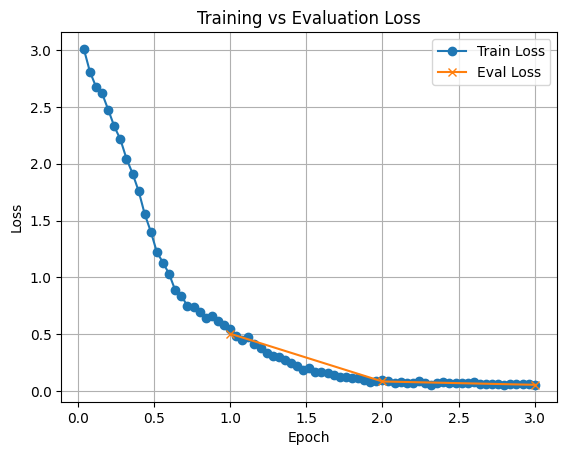

In [24]:
train_epochs, train_losses, eval_epochs, eval_losses = log_parser(trainer)

figure, ax = plt.subplots()

ax.plot(train_epochs, train_losses, marker="o", label="Train Loss")
ax.plot(eval_epochs, eval_losses, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [25]:
print(prompt)

Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A conducting triangular loop is placed near a long straight wire carrying i(t)=I sin(wt). Determine the RMS induced voltage.


In [26]:
response = generate_response(model, tokenizer, prompt)
response

'{"problem_type": "magnetic_induction", "difficulty": "advanced", "required_concepts": ["Faraday law", "magnetic flux", "time varying fields"], "reasoning_path": ["compute magnetic field", "integrate flux", "differentiate with respect to time"], "common_mistakes": ["incorrect flux integration", "missing negative sign"], "prerequisites": ["integration", "magnetostatics"]}'

In [27]:
df = evaluate_tutor_schema_df(model, tokenizer, test_dataset)
df.head()

,prompt,valid_json,pred_problem_type,actual_problem_type,problem_type_match,pred_difficulty,actual_difficulty,difficulty_match,pred_required_concepts,actual_required_concepts,...,equations_match,pred_final_answer,actual_final_answer,final_answer_match,pred_common_mistakes,actual_common_mistakes,mistakes_match,overall_match,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nYou are a helpful p...,True,electromagnetic_waves,electromagnetic_waves,True,advanced,advanced,True,"[Maxwell equations, wave impedance, phasors]","[Maxwell equations, wave impedance, phasors]",...,True,None,None,True,"[incorrect phase convention, mixing phasor and...","[incorrect phase convention, mixing phasor and...",True,True,"{""problem_type"": ""electromagnetic_waves"", ""dif...","{""problem_type"": ""electromagnetic_waves"", ""dif..."
1,Return ONLY valid JSON.\n\nYou are a helpful p...,True,electromagnetic_waves,electromagnetic_waves,True,advanced,advanced,True,"[Maxwell equations, wave impedance, phasors]","[Maxwell equations, wave impedance, phasors]",...,True,None,None,True,"[incorrect phase convention, mixing phasor and...","[incorrect phase convention, mixing phasor and...",True,True,"{""problem_type"": ""electromagnetic_waves"", ""dif...","{""problem_type"": ""electromagnetic_waves"", ""dif..."
2,Return ONLY valid JSON.\n\nYou are a helpful p...,True,magnetostatics,magnetostatics,True,beginner,beginner,True,"[Ampere law, cylindrical symmetry]","[Ampere law, cylindrical symmetry]",...,True,None,None,True,"[incorrect radial distance, wrong symmetry ass...","[incorrect radial distance, wrong symmetry ass...",True,True,"{""problem_type"": ""magnetostatics"", ""difficulty...","{""problem_type"": ""magnetostatics"", ""difficulty..."
3,Return ONLY valid JSON.\n\nYou are a helpful p...,True,student_support,student_support,True,beginner,beginner,True,"[wave propagation, time varying fields]","[wave propagation, time varying fields]",...,True,None,None,True,"[assuming instantaneous propagation, confusing...","[assuming instantaneous propagation, confusing...",True,True,"{""problem_type"": ""student_support"", ""difficult...","{""problem_type"": ""student_support"", ""difficult..."
4,Return ONLY valid JSON.\n\nYou are a helpful p...,True,magnetostatics,magnetostatics,True,beginner,beginner,True,"[Ampere law, cylindrical symmetry]","[Ampere law, cylindrical symmetry]",...,True,None,None,True,"[incorrect radial distance, wrong symmetry ass...","[incorrect radial distance, wrong symmetry ass...",True,True,"{""problem_type"": ""magnetostatics"", ""difficulty...","{""problem_type"": ""magnetostatics"", ""difficulty..."


In [28]:
df.problem_type_match.value_counts()

,count
problem_type_match,
True,100


In [29]:
df.difficulty_match.value_counts()

,count
difficulty_match,
True,100


In [30]:
df.final_answer_match.value_counts()

,count
final_answer_match,
True,100


### LoRA Training v2

In [31]:
trainer.args.num_train_epochs = 3
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.032712,0.035094
2,0.028921,0.029945
3,0.028665,0.027534


TrainOutput(global_step=375, training_loss=0.03412279152870178, metrics={'train_runtime': 457.504, 'train_samples_per_second': 3.279, 'train_steps_per_second': 0.82, 'total_flos': 495205364390400.0, 'train_loss': 0.03412279152870178})

### Model Evaluation v2

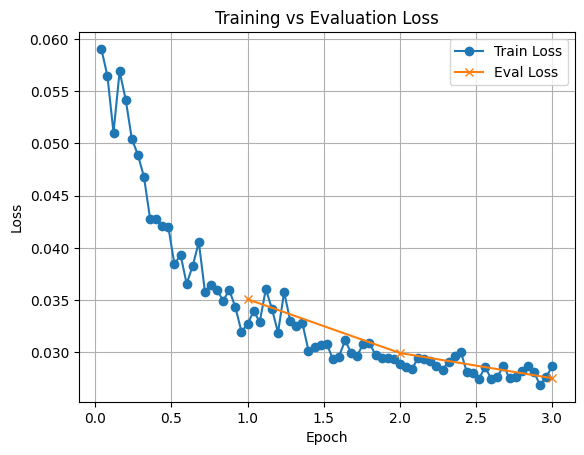

In [32]:
train_epochs, train_losses, eval_epochs, eval_losses = log_parser(trainer)

figure, ax = plt.subplots()

ax.plot(train_epochs, train_losses, marker="o", label="Train Loss")
ax.plot(eval_epochs, eval_losses, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [33]:
print(prompt)

Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A conducting triangular loop is placed near a long straight wire carrying i(t)=I sin(wt). Determine the RMS induced voltage.


In [34]:
generate_response(model, tokenizer, prompt)

'{"problem_type": "magnetic_induction", "difficulty": "advanced", "required_concepts": ["Faraday law", "magnetic flux", "time varying fields"], "reasoning_path": ["compute magnetic field", "integrate flux", "differentiate with respect to time"], "common_mistakes": ["incorrect flux integration", "missing negative sign"], "prerequisites": ["integration", "magnetostatics"]}'

In [35]:
df_2 = evaluate_tutor_schema_df(model, tokenizer, test_dataset)
df_2.head()

,prompt,valid_json,pred_problem_type,actual_problem_type,problem_type_match,pred_difficulty,actual_difficulty,difficulty_match,pred_required_concepts,actual_required_concepts,...,equations_match,pred_final_answer,actual_final_answer,final_answer_match,pred_common_mistakes,actual_common_mistakes,mistakes_match,overall_match,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nYou are a helpful p...,True,electromagnetic_waves,electromagnetic_waves,True,advanced,advanced,True,"[Maxwell equations, wave impedance, phasors]","[Maxwell equations, wave impedance, phasors]",...,True,None,None,True,"[incorrect phase convention, mixing phasor and...","[incorrect phase convention, mixing phasor and...",True,True,"{""problem_type"": ""electromagnetic_waves"", ""dif...","{""problem_type"": ""electromagnetic_waves"", ""dif..."
1,Return ONLY valid JSON.\n\nYou are a helpful p...,True,electromagnetic_waves,electromagnetic_waves,True,advanced,advanced,True,"[Maxwell equations, wave impedance, phasors]","[Maxwell equations, wave impedance, phasors]",...,True,None,None,True,"[incorrect phase convention, mixing phasor and...","[incorrect phase convention, mixing phasor and...",True,True,"{""problem_type"": ""electromagnetic_waves"", ""dif...","{""problem_type"": ""electromagnetic_waves"", ""dif..."
2,Return ONLY valid JSON.\n\nYou are a helpful p...,True,magnetostatics,magnetostatics,True,beginner,beginner,True,"[Ampere law, cylindrical symmetry]","[Ampere law, cylindrical symmetry]",...,True,None,None,True,"[incorrect radial distance, wrong symmetry ass...","[incorrect radial distance, wrong symmetry ass...",True,True,"{""problem_type"": ""magnetostatics"", ""difficulty...","{""problem_type"": ""magnetostatics"", ""difficulty..."
3,Return ONLY valid JSON.\n\nYou are a helpful p...,True,student_support,student_support,True,beginner,beginner,True,"[wave propagation, time varying fields]","[wave propagation, time varying fields]",...,True,None,None,True,"[assuming instantaneous propagation, confusing...","[assuming instantaneous propagation, confusing...",True,True,"{""problem_type"": ""student_support"", ""difficult...","{""problem_type"": ""student_support"", ""difficult..."
4,Return ONLY valid JSON.\n\nYou are a helpful p...,True,magnetostatics,magnetostatics,True,beginner,beginner,True,"[Ampere law, cylindrical symmetry]","[Ampere law, cylindrical symmetry]",...,True,None,None,True,"[incorrect radial distance, wrong symmetry ass...","[incorrect radial distance, wrong symmetry ass...",True,True,"{""problem_type"": ""magnetostatics"", ""difficulty...","{""problem_type"": ""magnetostatics"", ""difficulty..."


In [36]:
df_2.problem_type_match.value_counts()

,count
problem_type_match,
True,100


In [37]:
df_2.difficulty_match.value_counts()

,count
difficulty_match,
True,100


In [38]:
df_2.final_answer_match.value_counts()

,count
final_answer_match,
True,100


In [39]:
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_v2")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_v2")

('/content/model-alignment-lab-workshop_ucsd/outputs/smollm-em-tutor-lora/20260513_230919_final_adapter_v2/tokenizer_config.json',
 '/content/model-alignment-lab-workshop_ucsd/outputs/smollm-em-tutor-lora/20260513_230919_final_adapter_v2/chat_template.jinja',
 '/content/model-alignment-lab-workshop_ucsd/outputs/smollm-em-tutor-lora/20260513_230919_final_adapter_v2/tokenizer.json')

### Full Circle


In [40]:
prompt = """Return ONLY valid JSON.

You are a helpful personal electromagnetics tutor.
Provide structured reasoning and educational guidance.

Problem:
A uniformly charged sphere has radius R and charge density ρ. Find the electric field inside and outside the sphere."""

structured_output = generate_response(model, tokenizer, prompt)
print(structured_output)

{"problem_type": "electrostatics", "difficulty": "intermediate", "required_concepts": ["Gauss law", "spherical symmetry", "charge enclosure"], "reasoning_path": ["choose Gaussian surface", "compute enclosed charge", "apply Gauss law"], "common_mistakes": ["incorrect enclosed charge", "wrong Gaussian surface"], "prerequisites": ["Coulomb law", "surface integrals"]}


In [41]:
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype="auto",
    device_map="auto"
)
print(base_model)


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 960, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=960, out_features=960, bias=False)
          (k_proj): Linear(in_features=960, out_features=320, bias=False)
          (v_proj): Linear(in_features=960, out_features=320, bias=False)
          (o_proj): Linear(in_features=960, out_features=960, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=960, out_features=2560, bias=False)
          (up_proj): Linear(in_features=960, out_features=2560, bias=False)
          (down_proj): Linear(in_features=2560, out_features=960, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((960,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((960,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((960,), eps=1e-05)
    (r

In [42]:
prompt_final = f"""
You are a helpful electromagnetics tutor.

Given the structured analysis below, explain the problem
to a student in a natural educational way.

Structured analysis:
{structured_output}

Tutor explanation:
"""
response = generate_response(base_model, tokenizer, prompt_final, max_new_tokens=500)
print(response)

"To solve this problem, we need to understand the concept of electric field and how it relates to the charge distribution in a system. The problem involves finding the enclosed charge within a given Gaussian surface.

First, we need to choose a Gaussian surface. This is a way to enclose the charge distribution in a specific region of space. The choice of Gaussian surface depends on the nature of the problem and the information we have about the charge distribution.

Once we have chosen the Gaussian surface, we can compute the enclosed charge using the formula for the enclosed charge. This involves integrating the electric field over the surface of the Gaussian surface.

After computing the enclosed charge, we can apply the Gauss law to find the total enclosed charge. This law states that the total enclosed charge is equal to the charge enclosed by the Gaussian surface.

Finally, we need to check if our solution is correct. We can do this by plugging the values back into the problem and

### Rank Reduction

In [43]:
peft_config = LoraConfig(
    r=4,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","v_proj"]
)

model = get_peft_model(base_model, peft_config).to(base_model.device)
model.train()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=4, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=4, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Line

In [44]:
training_args = SFTConfig(
    output_dir=str(output_dir/"smollm-em-tutor-lora-r4"),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    dataset_text_field="text",
    use_cpu=False,
    bf16=False,
    fp16=False,
)

In [45]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.549016,0.511656


In [ ]:
final_path = str(output_dir/"smollm-em-tutor-lora-r4")
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_v1")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_v1")

In [ ]:
trainer.state.log_history

In [ ]:
train_epochs, train_losses, eval_epochs, eval_losses = log_parser(trainer)

figure, ax = plt.subplots()

ax.plot(train_epochs, train_losses, marker="o", label="Train Loss")
ax.plot(eval_epochs, eval_losses, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [ ]:
print(prompt)

In [ ]:
response = generate_response(model, tokenizer, prompt)
response

In [ ]:
df = evaluate_tutor_schema_df(model, tokenizer, test_dataset)
df.head()

In [ ]:
df.problem_type_match.value_counts()

In [ ]:
df.difficulty_match.value_counts()

In [ ]:
df.final_answer_match.value_counts()

## Next Steps

### Experiment 1: Scale to Larger Base Models
Repeat the same fine-tuning workflow using larger models to observe differences in alignment quality and generalization.

**Suggested models:**
- `Qwen/Qwen2.5-3B-Instruct`
- `Qwen/Qwen2.5-7B-Instruct`
- `mistralai/Mistral-7B-v0.1`

**What to observe:**
- Does the model require fewer examples to align?
- Does it better preserve general capabilities?
- How do latency and memory usage scale?

---

### Experiment 2: Increase LoRA Rank
Try increasing the LoRA rank (`r`) to give the model more capacity to adapt.

**Suggested values:**
- `r = 16`
- `r = 32`
- `r = 64`

**Key idea:**
Higher rank allows the model to **override strong base model priors**, which is especially useful for structured outputs like JSON.

**Tradeoffs:**
- Increased memory usage
- Potential overfitting if dataset is small

---

### Experiment 3: Tune LoRA Hyperparameters
Experiment with additional LoRA settings to improve performance.

**Parameters to explore:**
- `lora_alpha` (scaling factor)
- `lora_dropout` (regularization)
- Target modules (e.g., attention layers only vs all linear layers)

**Ideas:**
- Increase `lora_alpha` to amplify learned updates
- Reduce dropout if the model is underfitting
- Apply LoRA selectively to different parts of the model

---

### Experiment 4: Use QLoRA for Larger Models
When working with larger models (e.g., 7B+), use QLoRA to reduce memory requirements.

**Benefits:**
- Enables fine-tuning with limited GPU memory
- Maintains strong performance with 4-bit quantization

**When to use:**
- GPU memory becomes a bottleneck
- Scaling beyond smaller models is required